In [1]:
from __future__ import annotations

from collections import defaultdict

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from matplotlib.patches import Patch
from tqdm import tqdm

import gymnasium as gym
from utils import (
    BlackjackEnvironment,
    AgentRandom,
    AgentQL,
    AgentSARSA,
    AgentDQL
)

In [19]:
env_random_c = BlackjackEnvironment(include_count=True)
env_random = BlackjackEnvironment(include_count=False)
env_ql_c = BlackjackEnvironment(include_count=True)
env_ql = BlackjackEnvironment(include_count=False)
env_sarsa_c = BlackjackEnvironment(include_count=True)
env_sarsa = BlackjackEnvironment(include_count=False)
env_dql_c = BlackjackEnvironment(include_count=True)
env_dql = BlackjackEnvironment(include_count=False)

### Evaluate Random

In [3]:
agent_rand = AgentRandom()
balance_rand = [50]
obs = env_random.reset()

while balance_rand[-1] > 0:
    action = agent_rand.get_action(env_random)
    obs, reward, terminated = env_random.step(action)

    if reward == 0:
        pass
    else:
        balance_rand.append(balance_rand[-1] + reward)
        env_random.reset()

    if terminated:
        env_random.reset()

### Train Q-Learning

In [4]:
# hyperparameters
learning_rate = 0.001
n_episodes = 1_000_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

agent_ql = AgentQL(
    env=env_ql,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [5]:
rewards_ql = []
for episode in tqdm(range(n_episodes)):
    obs = env_ql.reset()
    done = False

    # play one episode
    r = 0
    while not done:
        action = agent_ql.get_action(env_ql, obs)
        next_obs, reward, terminated = env_ql.step(action)
        r += reward

        # update the agent
        agent_ql.update(obs, action, reward, terminated, next_obs)

        # update if the environment is done and the current obs
        done = terminated
        obs = next_obs
    rewards_ql.append(r)

    agent_ql.decay_epsilon()

100%|██████████| 1000000/1000000 [00:54<00:00, 18292.66it/s]


In [6]:
balance_ql = [50]

obs = env_ql.reset()

while balance_ql[-1] > 0:
    action = agent_ql.get_action(env_ql, obs)
    obs, reward, terminated = env_ql.step(action)
    
    if reward == 0:
        pass
    else:
        balance_ql.append(balance_ql[-1] + reward)
        env_ql.reset()

    if terminated:
        env_ql.reset()

### Train SARSA

In [7]:
# hyperparameters
learning_rate = 0.001
n_episodes = 1_000_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.01

agent_sarsa = AgentSARSA(
    env=env_sarsa,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [8]:
rewards_sarsa = []
for episode in tqdm(range(n_episodes)):
    obs = env_sarsa.reset()
    action = agent_sarsa.get_action(env_sarsa, obs)  # Choose initial action
    done = False

    r = 0
    while not done:
        next_obs, reward, terminated = env_sarsa.step(action)
        r += reward
        next_action = agent_sarsa.get_action(env_sarsa, next_obs)  # SARSA: Get next action

        # update the agent
        agent_sarsa.update(obs, action, reward, next_obs, next_action, terminated)

        # update if the environment is done and the current obs
        done = terminated
        obs = next_obs
    rewards_sarsa.append(r)

    agent_sarsa.decay_epsilon()

100%|██████████| 1000000/1000000 [00:42<00:00, 23476.81it/s]


In [9]:
balance_sarsa = [50]

obs = env_sarsa.reset()

while balance_sarsa[-1] > 0:
    action = agent_sarsa.get_action(env_sarsa, obs)
    obs, reward, terminated = env_sarsa.step(action)
    if reward == 0:
        pass
    else:
        balance_sarsa.append(balance_sarsa[-1] + reward)
        env_sarsa.reset()
        continue

    if terminated:
        env_sarsa.reset()
        continue

### Evaluate Random

In [10]:
agent_rand_c = AgentRandom()
balance_rand_c = [50]
obs = env_random_c.reset()

while balance_rand_c[-1] > 0:
    action = agent_rand_c.get_action(env_random_c)
    obs, reward, terminated = env_random_c.step(action)

    if reward == 0:
        pass
    else:
        balance_rand_c.append(balance_rand_c[-1] + reward)
        env_random_c.reset()

    if terminated:
        env_random_c.reset()

### Train Q-Learning

In [11]:
# hyperparameters
learning_rate = 0.001
n_episodes = 1_000_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)  # reduce the exploration over time
final_epsilon = 0.1

agent_ql_c = AgentQL(
    env=env_ql_c,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [12]:
rewards_ql_c = []
for episode in tqdm(range(n_episodes)):
    obs = env_ql_c.reset()
    done = False

    # play one episode
    r = 0
    while not done:
        action = agent_ql_c.get_action(env_ql_c, obs)
        next_obs, reward, terminated = env_ql_c.step(action)
        r += reward

        # update the agent
        agent_ql_c.update(obs, action, reward, terminated, next_obs)

        # update if the environment is done and the current obs
        done = terminated
        obs = next_obs
    rewards_ql_c.append(r)

    agent_ql_c.decay_epsilon()

100%|██████████| 1000000/1000000 [00:56<00:00, 17612.74it/s]


In [13]:
balance_ql_c = [50]

obs = env_ql_c.reset()

while balance_ql_c[-1] > 0:
    action = agent_ql_c.get_action(env_ql_c, obs)
    obs, reward, terminated = env_ql_c.step(action)
    
    if reward == 0:
        pass
    else:
        balance_ql_c.append(balance_ql_c[-1] + reward)
        env_ql_c.reset()

    if terminated:
        env_ql_c.reset()

### Train SARSA

In [14]:
# hyperparameters
learning_rate = 0.001
n_episodes = 1_000_000
start_epsilon = 1.0
epsilon_decay = start_epsilon / (n_episodes / 2)
final_epsilon = 0.01

agent_sarsa_c = AgentSARSA(
    env=env_sarsa_c,
    learning_rate=learning_rate,
    initial_epsilon=start_epsilon,
    epsilon_decay=epsilon_decay,
    final_epsilon=final_epsilon,
)

In [15]:
rewards_sarsa_c = []
for episode in tqdm(range(n_episodes)):
    obs = env_sarsa_c.reset()
    action = agent_sarsa_c.get_action(env_sarsa_c, obs)  # Choose initial action
    done = False

    r = 0
    while not done:
        next_obs, reward, terminated = env_sarsa_c.step(action)
        r += reward
        next_action = agent_sarsa_c.get_action(env_sarsa_c, next_obs)  # SARSA: Get next action

        # update the agent
        agent_sarsa_c.update(obs, action, reward, next_obs, next_action, terminated)

        # update if the environment is done and the current obs
        done = terminated
        obs = next_obs
    rewards_sarsa_c.append(r)

    agent_sarsa_c.decay_epsilon()

100%|██████████| 1000000/1000000 [00:43<00:00, 23000.83it/s]


In [16]:
balance_sarsa_c = [50]

obs = env_sarsa_c.reset()

while balance_sarsa_c[-1] > 0:
    action = agent_sarsa_c.get_action(env_sarsa_c, obs)
    obs, reward, terminated = env_sarsa_c.step(action)
    if reward == 0:
        pass
    else:
        balance_sarsa_c.append(balance_sarsa_c[-1] + reward)
        env_sarsa_c.reset()
        continue

    if terminated:
        env_sarsa_c.reset()
        continue

In [25]:
balance_dql_c = [50]

obs = env_dql_c.reset()

while balance_dql_c[-1] > 0:
    action = agent_sarsa_c.get_action(env_dql_c, obs)
    obs, reward, terminated = env_dql_c.step(action)
    if reward == 0:
        pass
    else:
        balance_dql_c.append(balance_dql_c[-1] + reward)
        env_dql_c.reset()
        continue

    if terminated:
        env_dql_c.reset()
        continue

In [26]:
balance_dql = [50]

obs = env_dql.reset()

while balance_dql[-1] > 0:
    action = agent_sarsa.get_action(env_dql, obs)
    obs, reward, terminated = env_dql.step(action)
    if reward == 0:
        pass
    else:
        balance_dql.append(balance_dql[-1] + reward)
        env_dql.reset()
        continue

    if terminated:
        env_dql.reset()
        continue

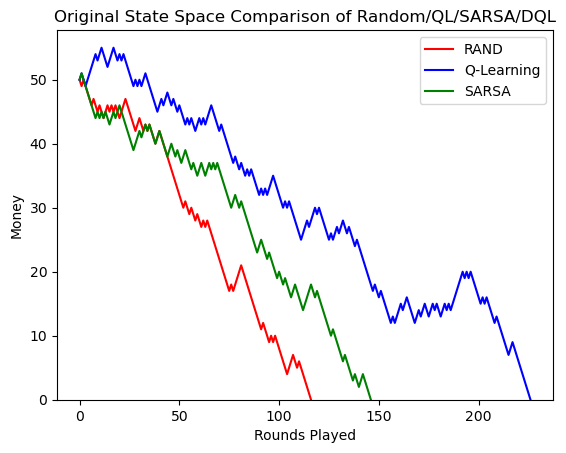

In [23]:
plt.plot(balance_rand, c='red', label='RAND')
plt.plot(balance_ql, c='blue', label='Q-Learning')
plt.plot(balance_sarsa, c='green', label='SARSA')

plt.title("Original State Space Comparison of Random/QL/SARSA/DQL")
plt.xlabel("Rounds Played")
plt.ylabel("Money")
plt.ylim(0)
plt.legend()
plt.show()

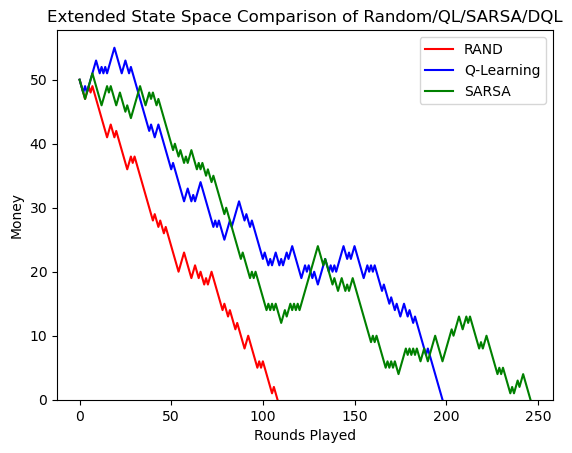

In [24]:
plt.plot(balance_rand_c, c='red', label='RAND')
plt.plot(balance_ql_c, c='blue', label='Q-Learning')
plt.plot(balance_sarsa_c, c='green', label='SARSA')

plt.title("Extended State Space Comparison of Random/QL/SARSA/DQL")
plt.xlabel("Rounds Played")
plt.ylabel("Money")
plt.ylim(0)
plt.legend()
plt.show()

### Training DQN

In [ ]:
# hyperparameters
learning_rate = 0.001
n_episodes = 100_000

agent_dql_c = AgentDQL(
    env=env_dql_c,
    learning_rate=learning_rate,
    include_count=True
)

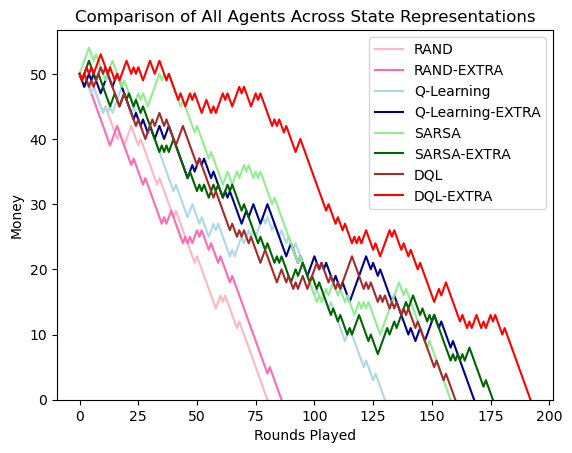

In [29]:
plt.plot(balance_rand, c='lightpink', label='RAND')
plt.plot(balance_rand_c, c='hotpink', label='RAND-EXTRA')
plt.plot(balance_ql, c='lightblue', label='Q-Learning')
plt.plot(balance_ql_c, c='darkblue', label='Q-Learning-EXTRA')
plt.plot(balance_sarsa, c='lightgreen', label='SARSA')
plt.plot(balance_sarsa_c, c='darkgreen', label='SARSA-EXTRA')
plt.plot(balance_dql, c='brown', label='DQL')
plt.plot(balance_dql_c, c='red', label='DQL-EXTRA')

plt.title("Comparison of All Agents Across State Representations")
plt.xlabel("Rounds Played")
plt.ylabel("Money")
plt.ylim(0)
plt.legend()
plt.show()